# Exploring our Dataset

In this dataset, we are provided 5000 images. Some of them are Tumors, some of them are Healthy. It's somewhat even, 3000 tumors and 200 healthy

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from collections import Counter
import pandas as pd

sns.set()

dataset_healthy = "./dataset/healthy"
dataset_tumor = "./dataset/tumor"
healthy_list = os.listdir(dataset_healthy)
tumor_list = os.listdir(dataset_tumor)

print("AMOUNT OF HEALTHY IMAGES: ", len(healthy_list)) 
print("AMOUNT OF TUMOR IMAGES: ", len(tumor_list)) 

AMOUNT OF HEALTHY IMAGES:  2000
AMOUNT OF TUMOR IMAGES:  3000


## Tumor subtypes
Within the Tumor images, they have been subclassified in the type of tumor they are. we have:
- `meningioma`: tumors that originate from the meninges, the layers of tissue covering the brain and spinal cord. Typically slow-growing and benign, but can still cause pressure effects
- `pituitary`: Tumors located in the pituitary gland, which can affect hormone production and lead to endocrine symptoms. Often small but clinically significant
- `glioma`: Tumors arising from glial cells in the brain. Gliomas include astrocytomas, oligodendrogliomas, and other malignant brain tumors, often aggressive in nature.
- `other` / `tumor`: Images labeled simply as tumor without a specific subtype. These may represent unknown, rare, or mixed tumor types that were not subclassified during dataset preparation

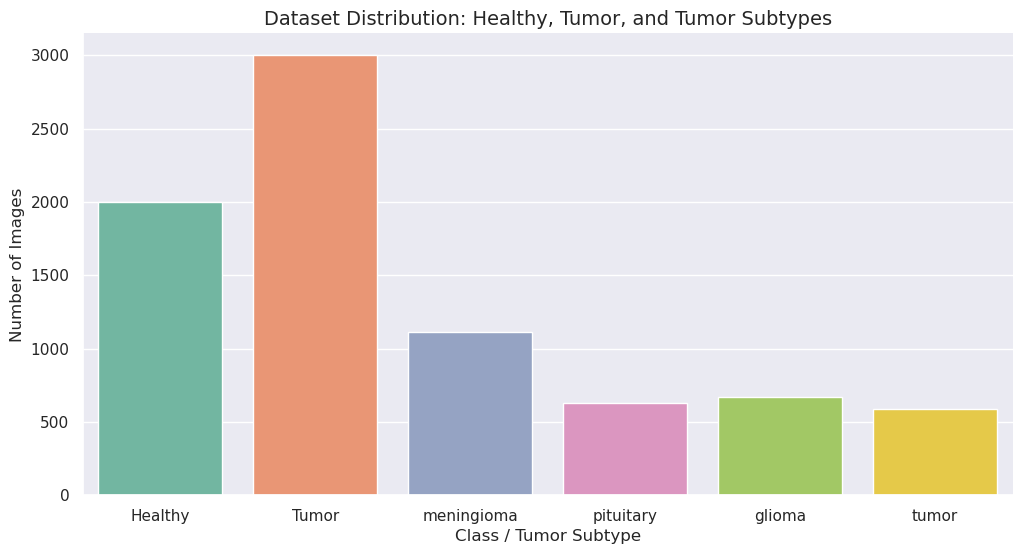

In [2]:
tumor_subtypes = [name.split()[0] for name in tumor_list]
counts = Counter(tumor_subtypes)

# count healthy and tumor images
healthy_count = len(healthy_list)

# count tumor subtypes
tumor_subtypes = [name.split()[0] for name in tumor_list]
tumor_count = Counter(tumor_subtypes)

# combine into a single DataFrame for Seaborn
data = {"Class": ["Healthy"] + list(tumor_count.keys()),
        "Count": [healthy_count] + list(tumor_count.values())}

df = pd.DataFrame(data)
healthy_count = len(healthy_list)
tumor_subtypes = [name.split()[0] for name in tumor_list]
tumor_count = Counter(tumor_subtypes)
total_tumor_count = sum(tumor_count.values())

classes = ["Healthy", "Tumor"] + list(tumor_count.keys())
counts = [healthy_count, total_tumor_count] + list(tumor_count.values())
df = pd.DataFrame({"Class": classes, "Count": counts})

plt.figure(figsize=(12,6))
sns.barplot(x="Class", y="Count", data=df, hue="Class", legend=False, palette=sns.color_palette("Set2", len(df)))
plt.title("Dataset Distribution: Healthy, Tumor, and Tumor Subtypes", fontsize=14)
plt.ylabel("Number of Images")
plt.xlabel("Class / Tumor Subtype")
sns.despine()
plt.show()

The `Tumor` column is the total amount of tumor images, and the last 4 are the subclassified tumor images. In total, we have 5000 images.